In [ ]:
import numpy as np
import matplotlib.pyplot as pl
from soilice import model

In [ ]:
from soilice import copyConstitutiveFuns
copyConstitutiveFuns()

In [ ]:
from src_constitutiveFunctions import (
    thetaFun, CFun, KFun,
    thermalKfun, GCEFun, SFCslope, CBFun
    )
from soilice import writeDefaultPars
from numba import types
from numba.typed import Dict

In [3]:
def MakeDictFloat():
    d=Dict.empty(
    key_type=types.unicode_type,
    value_type=types.float64,)
    return d

In [4]:
# writeDefaultPars()

In [5]:
x=model()
x.readPars()
pars=MakeDictFloat()
const=MakeDictFloat()
for i in x.pars: pars[i]=x.pars[i]
for i in x.const: const[i]=x.const[i]

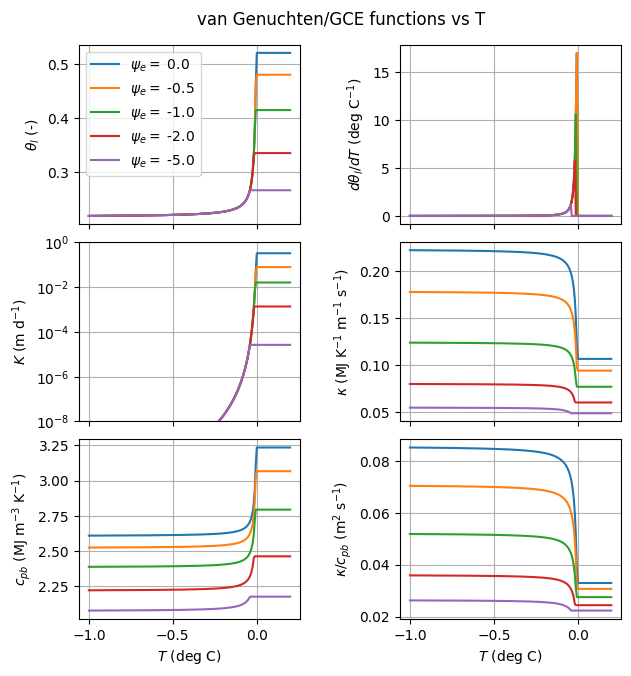

In [6]:
n=200
log=False
if log: 
    T=-np.logspace(-4,0,n)
    psif=GCEFun(T,pars,const)
else:
    T=np.linspace(-1,0.2,n)
    psif=GCEFun(T,pars,const)
    T=-T
psi_arr=np.array([0,-.5,-1,-2,-5])

fig=pl.figure(figsize=(7,7))

pl.subplot(3,2,1)
for psie in psi_arr:
    pl.plot(-T,thetaFun(np.minimum(psif,psie),pars),label=fr'$\psi_e = $ {psie}')
pl.grid()
pl.ylabel(r'$\theta_l$ (-)')
# pl.xlabel(r'$T$ (deg C)')
if log: pl.gca().set_xscale('log')
if log: pl.xlim(1,1e-4)
pl.legend()
yl=pl.gca().get_ylim()
pl.gca().set_xticklabels([])

pl.subplot(3,2,2)
for psie in psi_arr:
    # pl.plot(-T,CFun(np.minimum(psif,psie),pars),label=str(psie))
    pl.plot(-T,SFCslope(np.full(n,psie),np.minimum(psif,psie),pars,const),label=str(psie))
pl.grid()
pl.ylabel(r'$d\theta_l/dT$ (deg C$^{-1}$)')
# pl.xlabel(r'$T$ (deg C)')
if log: pl.gca().set_xscale('log')
if log: pl.xlim(1,1e-4)
yl=pl.gca().get_ylim()
pl.gca().set_xticklabels([])

pl.subplot(3,2,3)
for psie in psi_arr:
    pl.plot(-T,KFun(np.minimum(psif,psie),np.minimum(psif,psie),pars,const),label=str(psie))
pl.grid()
pl.ylabel(r'$K$ (m d$^{-1}$)')
# pl.xlabel(r'$T$ (deg C)')
if log: pl.gca().set_xscale('log')
if log: pl.xlim(1,1e-4)
pl.gca().set_yscale('log')
# yl=pl.gca().get_ylim()
pl.ylim(1e-8,1)
pl.gca().set_xticklabels([])

pl.subplot(3,2,4)
for psie in psi_arr:
    pl.plot(-T,thermalKfun(np.full(n,psie),np.minimum(psif,psie),T,pars,const)/1e6,label=str(psie))
pl.grid()
pl.ylabel(r'$\kappa$ (MJ K$^{-1}$ m$^{-1}$ s$^{-1}$)')
# pl.xlabel(r'$T$ (deg C)')
if log: pl.gca().set_xscale('log')
if log: pl.xlim(1,1e-4)
# pl.ylim(0.005,0.022)
yl=pl.gca().get_ylim()
pl.gca().set_xticklabels([])

pl.subplot(3,2,5)
for psie in psi_arr:
    pl.plot(-T,CBFun(np.full(n,psie),np.minimum(psif,psie),pars,const)/1e6,label=str(psie))
pl.grid()
pl.ylabel(r'$c_{pb}$ (MJ m$^{-3}$ K$^{-1}$)')
pl.xlabel(r'$T$ (deg C)')
if log: pl.gca().set_xscale('log')
if log: pl.xlim(1,1e-4)
# pl.ylim(0.005,0.022)
yl=pl.gca().get_ylim()

pl.subplot(3,2,6)
for psie in psi_arr:
    pl.plot(-T,thermalKfun(np.full(n,psie),np.minimum(psif,psie),T,pars,const)/CBFun(np.full(n,psie),np.minimum(psif,psie),pars,const),label=str(psie))
pl.grid()
pl.ylabel(r'$\kappa/c_{pb}$ (m$^2$ s$^{-1}$)')
pl.xlabel(r'$T$ (deg C)')
if log: pl.gca().set_xscale('log')
if log: pl.xlim(1,1e-4)
# pl.ylim(0.005,0.022)
yl=pl.gca().get_ylim()


fig.suptitle('van Genuchten/GCE functions vs T')
pl.subplots_adjust(hspace=0.1,wspace=0.45,top=0.93)
pl.savefig('figures/00_properties_T.svg')

<Figure size 700x1500 with 0 Axes>

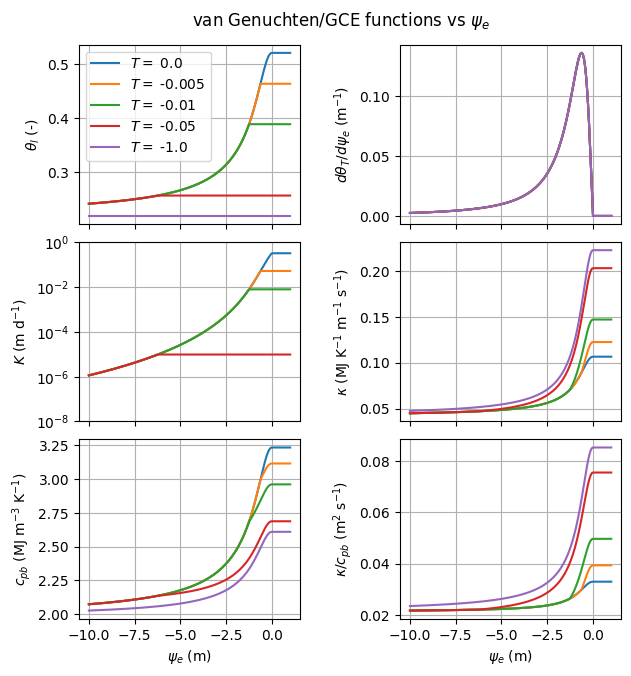

In [7]:
n=200
log=False
if log: 
    psie=np.logspace(-2,2,n)
    xx=-psie
else:
    psie=np.linspace(-10,1,n)
    xx=psie

Tarr=np.array([0,-.005,-.01,-0.05,-1])

pl.figure(figsize=(7,15))

fig=pl.figure(figsize=(7,7))

pl.subplot(3,2,1)
for T in Tarr:
    psif=np.full(n,GCEFun(np.array([T]),pars,const))
    pl.plot(xx,thetaFun(np.minimum(psif,psie),pars),label=fr'$T = $ {T}')
pl.grid()
pl.ylabel(r'$\theta_l$ (-)')
# pl.xlabel(r'$T$ (deg C)')
if log: pl.gca().set_xscale('log')
if log: pl.xlim(1,1e-4)
pl.legend()
yl=pl.gca().get_ylim()
pl.gca().set_xticklabels([])

pl.subplot(3,2,2)
for T in Tarr:
    psif=np.full(n,GCEFun(np.array([T]),pars,const))
    # pl.plot(xx,SFCslope(psie,np.minimum(psif,psie),pars,const),label=str(T))
    # pl.plot(xx,CFun(np.minimum(psif,psie),pars),label=str(T))
    pl.plot(xx,CFun(psie,pars),label=str(T))
pl.grid()
pl.ylabel(r'$d\theta_T/d\psi_e$ (m$^{-1}$)')
# pl.xlabel(r'$T$ (deg C)')
if log: pl.gca().set_xscale('log')
if log: pl.xlim(1,1e-4)
yl=pl.gca().get_ylim()
pl.gca().set_xticklabels([])

pl.subplot(3,2,3)
for T in Tarr:
    psif=np.full(n,GCEFun(np.array([T]),pars,const))
    pl.plot(xx,KFun(np.minimum(psif,psie),np.minimum(psif,psie),pars,const),label=str(T))
pl.grid()
pl.ylabel(r'$K$ (m d$^{-1}$)')
# pl.xlabel(r'$T$ (deg C)')
if log: pl.gca().set_xscale('log')
if log: pl.xlim(1,1e-4)
pl.gca().set_yscale('log')
# yl=pl.gca().get_ylim()
pl.ylim(1e-8,1)
pl.gca().set_xticklabels([])

pl.subplot(3,2,4)
for T in Tarr:
    psif=np.full(n,GCEFun(np.array([T]),pars,const))
    pl.plot(xx,thermalKfun(np.full(n,psie),np.minimum(psif,psie),T,pars,const)/1e6,label=str(T))
pl.grid()
pl.ylabel(r'$\kappa$ (MJ K$^{-1}$ m$^{-1}$ s$^{-1}$)')
# pl.xlabel(r'$T$ (deg C)')
if log: pl.gca().set_xscale('log')
if log: pl.xlim(1,1e-4)
# pl.ylim(0.005,0.022)
yl=pl.gca().get_ylim()
pl.gca().set_xticklabels([])

pl.subplot(3,2,5)
for T in Tarr:
    psif=np.full(n,GCEFun(np.array([T]),pars,const))
    pl.plot(xx,CBFun(np.full(n,psie),np.minimum(psif,psie),pars,const)/1e6,label=str(T))
pl.grid()
pl.ylabel(r'$c_{pb}$ (MJ m$^{-3}$ K$^{-1}$)')
pl.xlabel(r'$\psi_e$ (m)')
if log: pl.gca().set_xscale('log')
if log: pl.xlim(1,1e-4)
# pl.ylim(0.005,0.022)
yl=pl.gca().get_ylim()

pl.subplot(3,2,6)
for T in Tarr:
    psif=np.full(n,GCEFun(np.array([T]),pars,const))
    pl.plot(xx,thermalKfun(np.full(n,psie),np.minimum(psif,psie),T,pars,const)/CBFun(np.full(n,psie),np.minimum(psif,psie),pars,const),label=str(psie))
pl.grid()
pl.ylabel(r'$\kappa/c_{pb}$ (m$^2$ s$^{-1}$)')
pl.xlabel(r'$\psi_e$ (m)')
if log: pl.gca().set_xscale('log')
if log: pl.xlim(1,1e-4)
# pl.ylim(0.005,0.022)
yl=pl.gca().get_ylim()


fig.suptitle(r'van Genuchten/GCE functions vs $\psi_e$')
pl.subplots_adjust(hspace=0.1,wspace=0.45,top=0.93)
pl.savefig('figures/00_properties_psi.svg')

<Figure size 700x1500 with 0 Axes>

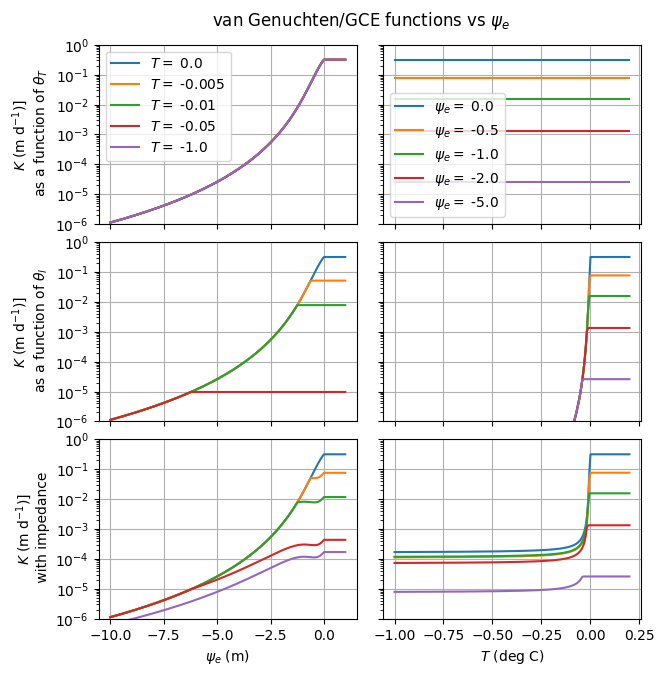

In [8]:
n=200
log=False
if log: 
    psie=np.logspace(-2,2,n)
    xx=-psie
else:
    psie=np.linspace(-10,1,n)
    xx=psie

Tarr=np.array([0,-.005,-.01,-0.05,-1])

pl.figure(figsize=(7,15))

fig=pl.figure(figsize=(7,7))

pl.subplot(3,2,1)
for T in Tarr:
    psif=np.full(n,GCEFun(np.array([T]),pars,const))
    pars['impedance']=0.
    pl.plot(xx,KFun(np.full(n,psie),np.minimum(psif,psie),pars,const),label=fr'$T = $ {T}')
pl.grid()
pl.ylabel('$K$ (m d$^{-1}$)]\n as a function of $\\theta_T$')
# pl.xlabel(r'$T$ (deg C)')
if log: pl.gca().set_xscale('log')
if log: pl.xlim(1,1e-4)
pl.gca().set_yscale('log')

pl.legend()
pl.ylim(1e-6,1)
pl.gca().set_xticklabels([])

pl.subplot(3,2,3)
for T in Tarr:
    psif=np.full(n,GCEFun(np.array([T]),pars,const))
    pars['impedance']=0.
    pl.plot(xx,KFun(np.minimum(psif,psie),np.minimum(psif,psie),pars,const),label=str(T))
pl.grid()
pl.ylabel('$K$ (m d$^{-1}$)]\n as a function of $\\theta_l$')
# pl.xlabel(r'$T$ (deg C)')
if log: pl.gca().set_xscale('log')
if log: pl.xlim(1,1e-4)
pl.gca().set_yscale('log')
# yl=pl.gca().get_ylim()
pl.ylim(1e-6,1)
pl.gca().set_xticklabels([])

pl.subplot(3,2,5)
for T in Tarr:
    psif=np.full(n,GCEFun(np.array([T]),pars,const))
    pars['impedance']=10.
    pl.plot(xx,KFun(np.full(n,psie),np.minimum(psif,psie),pars,const),label=str(T))
pl.grid()
pl.gca().set_yscale('log')
pl.ylabel('$K$ (m d$^{-1}$)]\n with impedance')
pl.xlabel(r'$\psi_e$ (m)')
if log: pl.gca().set_xscale('log')
if log: pl.xlim(1,1e-4)
# pl.ylim(0.005,0.022)
pl.ylim(1e-6,1)

if log: 
    T=-np.logspace(-4,0,n)
    psif=GCEFun(T,pars,const)
else:
    T=np.linspace(-1,0.2,n)
    psif=GCEFun(T,pars,const)
    T=-T
psi_arr=np.array([0,-.5,-1,-2,-5])

pl.subplot(3,2,2)
for psie in psi_arr:
    pars['impedance']=0.
    pl.plot(-T,KFun(np.full(n,psie),np.minimum(psif,psie),pars,const),label=fr'$\psi_e = $ {psie}')
pl.grid()
# pl.xlabel(r'$T$ (deg C)')
if log: pl.gca().set_xscale('log')
if log: pl.xlim(1,1e-4)
pl.gca().set_yscale('log')

pl.legend()
pl.ylim(1e-6,1)
pl.gca().set_xticklabels([])
pl.gca().set_yticklabels([])

pl.subplot(3,2,4)
for psie in psi_arr:
    pars['impedance']=0.
    pl.plot(-T,KFun(np.minimum(psif,psie),np.minimum(psif,psie),pars,const),label=str(psie))
pl.grid()
# pl.xlabel(r'$T$ (deg C)')
if log: pl.gca().set_xscale('log')
if log: pl.xlim(1,1e-4)
pl.gca().set_yscale('log')
# yl=pl.gca().get_ylim()
pl.ylim(1e-6,1)
pl.gca().set_xticklabels([])
pl.gca().set_yticklabels([])

pl.subplot(3,2,6)
for psie in psi_arr:
    pars['impedance']=10.
    pl.plot(-T,KFun(np.full(n,psie),np.minimum(psif,psie),pars,const),label=str(psie))
pl.grid()
pl.gca().set_yscale('log')
pl.xlabel(r'$T$ (deg C)')
if log: pl.gca().set_xscale('log')
if log: pl.xlim(1,1e-4)
# pl.ylim(0.005,0.022)
pl.ylim(1e-6,1)
pl.gca().set_yticklabels([])


fig.suptitle(r'van Genuchten/GCE functions vs $\psi_e$')
pl.subplots_adjust(hspace=0.1,wspace=0.1,top=0.93)
pl.savefig('figures/00_KFuns.svg')